## Project Title: Insurance Claim Risk Modeling for Healthcare Cost Anomalies


In [1]:
# import os
# print(os.getcwd())

```
second-project/
│
├── dataset/
│    └── healthcare_dataset.zip
│
└── notebook/
     └── insurance_claim_mod.ipynb
```


In [2]:
# Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load libraries
import zipfile

# Define the ZIP file path and the raw data filename inside the ZIP
zip_path = "../dataset/healthcare_dataset.zip"  
raw_data = "healthcare_dataset.csv"  

# Open the ZIP file and read the raw file
with zipfile.ZipFile(zip_path, 'r') as z:
    with z.open(raw_data) as f:
        # Load the raw file 
       insurance_claim_df = pd.read_csv(f)

In [4]:
# Print the first few rows to check the data
insurance_claim_df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [5]:
insurance_claim_df.shape

(55500, 15)

In [6]:
# Drop unnessary column
insurance_claim_df = insurance_claim_df.drop(["Blood Type", "Name"], axis=1)

In [7]:
# Check missing values
print(insurance_claim_df.isnull().sum())

Age                   0
Gender                0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64


## Exploratory Data Analysis (EDA)

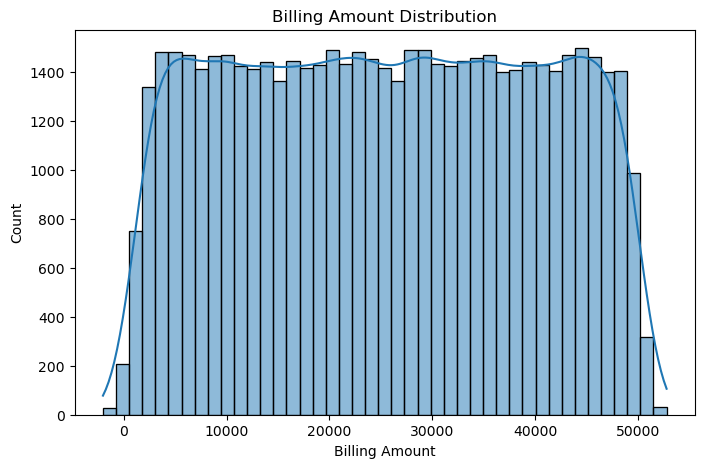

In [8]:
# Billing Amount Distribution
plt.figure(figsize=(8, 5))
sns.histplot(insurance_claim_df['Billing Amount'], kde=True)
plt.title('Billing Amount Distribution')
plt.show()

In [9]:
print(insurance_claim_df["Insurance Provider"].value_counts())
print(insurance_claim_df["Doctor"].value_counts())
print(insurance_claim_df["Hospital"].value_counts())

Insurance Provider
Cigna               11249
Medicare            11154
UnitedHealthcare    11125
Blue Cross          11059
Aetna               10913
Name: count, dtype: int64
Doctor
Michael Smith           27
Robert Smith            22
John Smith              22
Michael Johnson         20
James Smith             20
                        ..
Audrey Zimmerman DDS     1
Justin Banks             1
Joseph Williams Jr.      1
Jason Franklin           1
Jeffrey Moore            1
Name: count, Length: 40341, dtype: int64
Hospital
LLC Smith                      44
Ltd Smith                      39
Johnson PLC                    38
Smith Ltd                      37
Smith PLC                      36
                               ..
and Montoya Flores, Boyer       1
Carter and Dunn King,           1
Hall, Brown Black and           1
Peterson Scott and Thomas,      1
Moreno Murphy, Griffith and     1
Name: count, Length: 39876, dtype: int64


In [10]:
insurance_claim_df.columns

Index(['Age', 'Gender', 'Medical Condition', 'Date of Admission', 'Doctor',
       'Hospital', 'Insurance Provider', 'Billing Amount', 'Room Number',
       'Admission Type', 'Discharge Date', 'Medication', 'Test Results'],
      dtype='object')

In [11]:
# Create derived features -- stay duration and billing per day
insurance_claim_df['Stay_Duration'] = (pd.to_datetime(insurance_claim_df['Discharge Date']) - pd.to_datetime(insurance_claim_df['Date of Admission'])).dt.days
insurance_claim_df['Billing_per_Day'] = insurance_claim_df['Billing Amount'] / insurance_claim_df['Stay_Duration']

In [12]:
# Create Hospital Profile
hospital_profile = insurance_claim_df.groupby('Hospital').agg({
    'Billing Amount': ['count', 'mean'],
    'Stay_Duration': 'mean'
}).reset_index()

hospital_profile.columns = ['Hospital', 'Hospital_Visit_Frequency', 'Hospital_Avg_Billing', 'Hospital_Avg_Stay']

# Create Doctor Profile
doctor_profile = insurance_claim_df.groupby('Doctor').agg({
    'Billing Amount': ['count', 'mean'],
    'Stay_Duration': 'mean'
}).reset_index()

doctor_profile.columns = ['Doctor', 'Doctor_Visit_Frequency', 'Doctor_Avg_Billing', 'Doctor_Avg_Stay']

#  Merge Profiles Back to Original Dataset
insurance_claim_df = insurance_claim_df.merge(hospital_profile, on='Hospital', how='left')
insurance_claim_df = insurance_claim_df.merge(doctor_profile, on='Doctor', how='left')

In [13]:
insurance_claim_df.shape

(55500, 21)

In [14]:
insurance_claim_df.columns

Index(['Age', 'Gender', 'Medical Condition', 'Date of Admission', 'Doctor',
       'Hospital', 'Insurance Provider', 'Billing Amount', 'Room Number',
       'Admission Type', 'Discharge Date', 'Medication', 'Test Results',
       'Stay_Duration', 'Billing_per_Day', 'Hospital_Visit_Frequency',
       'Hospital_Avg_Billing', 'Hospital_Avg_Stay', 'Doctor_Visit_Frequency',
       'Doctor_Avg_Billing', 'Doctor_Avg_Stay'],
      dtype='object')

In [15]:
from sklearn.preprocessing import LabelEncoder

# Encoding categorical variables
cat_cols = ['Gender', 'Medical Condition', 'Insurance Provider', 'Admission Type', 'Medication', 'Test Results']
encoder = LabelEncoder()
for col in cat_cols:
    insurance_claim_df[col] = encoder.fit_transform(insurance_claim_df[col])

# Copy the dataset
insurance_df = insurance_claim_df.copy()

In [16]:
insurance_claim_df.head()

,Age,Gender,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,...,Medication,Test Results,Stay_Duration,Billing_per_Day,Hospital_Visit_Frequency,Hospital_Avg_Billing,Hospital_Avg_Stay,Doctor_Visit_Frequency,Doctor_Avg_Billing,Doctor_Avg_Stay
0,30,1,2,2024-01-31,Matthew Smith,Sons and Miller,1,18856.281306,328,2,...,3,2,2,9428.140653,7,20492.133443,13.571429,17,24790.303906,13.764706
1,62,1,5,2019-08-20,Samantha Davies,Kim Inc,3,33643.327287,265,1,...,1,1,6,5607.221214,6,24279.999236,13.166667,1,33643.327287,6.000000
2,76,0,5,2022-09-22,Tiffany Mitchell,Cook PLC,0,27955.096079,205,1,...,0,2,15,1863.673072,4,25877.277431,16.000000,1,27955.096079,15.000000
3,28,0,3,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",3,37909.782410,450,0,...,1,0,30,1263.659414,1,37909.782410,30.000000,1,37909.782410,30.000000
4,43,0,2,2022-09-19,Kathleen Hanna,White-White,0,14238.317814,458,2,...,4,0,20,711.915891,2,14238.317814,20.000000,2,14238.317814,20.000000


In [17]:
# Drop unnessary column
insurance_df = insurance_df.drop(["Doctor", "Hospital", 'Discharge Date', 'Date of Admission','Room Number'], axis=1)

In [18]:
print(insurance_df.shape)
print(insurance_df.head())

(55500, 16)
   Age  Gender  Medical Condition  Insurance Provider  Billing Amount  \
0   30       1                  2                   1    18856.281306   
1   62       1                  5                   3    33643.327287   
2   76       0                  5                   0    27955.096079   
3   28       0                  3                   3    37909.782410   
4   43       0                  2                   0    14238.317814   

   Admission Type  Medication  Test Results  Stay_Duration  Billing_per_Day  \
0               2           3             2              2      9428.140653   
1               1           1             1              6      5607.221214   
2               1           0             2             15      1863.673072   
3               0           1             0             30      1263.659414   
4               2           4             0             20       711.915891   

   Hospital_Visit_Frequency  Hospital_Avg_Billing  Hospital_Avg_Stay  \
0 

In [19]:
# Load the necessary libraries
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

# Scale the dataset
X = insurance_df.copy()

# Normalize the scores
scaler = MinMaxScaler()
# scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [20]:
import numpy as np

# Apply anomaly detection methods such as Isolation Forest
contamination_levels = [0.01, 0.05, 0.1, 0.15]

results = {}

for contamination in contamination_levels:
    iso_forest = IsolationForest(contamination=contamination, random_state=42)
    iso_forest.fit(X_scaled)
    
    preds = iso_forest.predict(X_scaled)
    # In Isolation Forest, -1 = outlier, 1 = normal
    n_outliers = np.sum(preds == -1)
    
    results[contamination] = n_outliers
    print(f"Contamination: {contamination}, Outliers detected: {n_outliers}")

print("\nSummary:", results)

Contamination: 0.01, Outliers detected: 555
Contamination: 0.05, Outliers detected: 2775
Contamination: 0.1, Outliers detected: 5550
Contamination: 0.15, Outliers detected: 8325

Summary: {0.01: 555, 0.05: 2775, 0.1: 5550, 0.15: 8325}


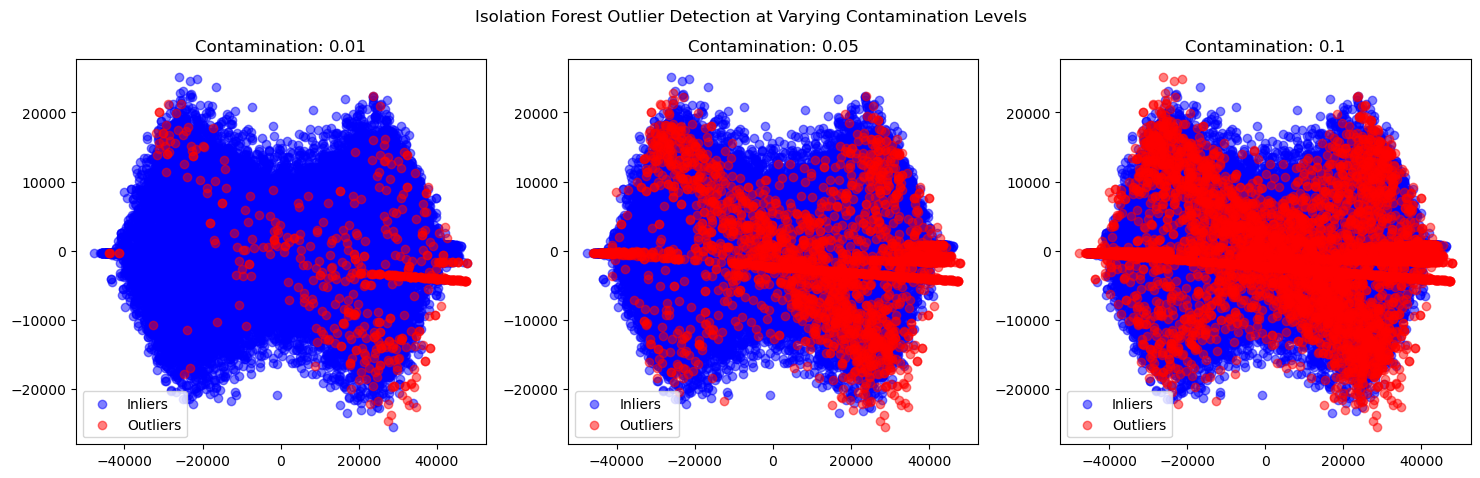

In [21]:
from sklearn.decomposition import PCA


contamination_values = [0.01, 0.05, 0.10]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Reduce to 2D 
X_pca = PCA(n_components=2).fit_transform(X)

for i, c in enumerate(contamination_values):
    clf = IsolationForest(contamination=c, random_state=42)
    preds = clf.fit_predict(X)
    is_outlier = preds == -1

    axes[i].scatter(X_pca[~is_outlier, 0], X_pca[~is_outlier, 1], 
                    c='blue', label='Inliers', alpha=0.5)
    axes[i].scatter(X_pca[is_outlier, 0], X_pca[is_outlier, 1], 
                    c='red', label='Outliers', alpha=0.5)
    axes[i].set_title(f"Contamination: {c}")
    axes[i].legend()

plt.suptitle("Isolation Forest Outlier Detection at Varying Contamination Levels")
plt.show()

Note: 
* At 0.01 contamination levele, the model is too conservative. With that in mind, 0.05 or 0.1 are often practical defaults since there is no domain knowledge available.

In [22]:
# Isolation Forest
iso_forest = IsolationForest(contamination=0.05, random_state=42)
iso_labels = iso_forest.fit_predict(X_scaled)

# 1 = normal, -1 = anomaly
insurance_df['IsoForest_Anomaly'] = iso_labels
insurance_claim_df['IsoForest_Anomaly'] = iso_labels

In [23]:
from sklearn.neighbors import LocalOutlierFactor

n_neighbors_list = [5, 10, 20, 50]
contamination = 0.05  

results = {}

for n in n_neighbors_list:
    lof = LocalOutlierFactor(n_neighbors=n, contamination=contamination)
    preds = lof.fit_predict(X_scaled)
    # In LOF: -1 = outlier, 1 = normal
    n_outliers = np.sum(preds == -1)
    
    results[n] = n_outliers
    print(f"n_neighbors: {n}, Outliers detected: {n_outliers}")

print("\nSummary:", results)

n_neighbors: 5, Outliers detected: 2775
n_neighbors: 10, Outliers detected: 2775
n_neighbors: 20, Outliers detected: 2775
n_neighbors: 50, Outliers detected: 2775

Summary: {5: 2775, 10: 2775, 20: 2775, 50: 2775}


In [24]:
# Local Outlier Factor (LOF)
lof = LocalOutlierFactor(n_neighbors=5, contamination=0.05)
lof_labels = lof.fit_predict(X_scaled)

# 1 = normal, -1 = anomaly
insurance_df['LOF_Anomaly'] = lof_labels
insurance_claim_df['LOF_Anomaly'] = lof_labels

1735/1735 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


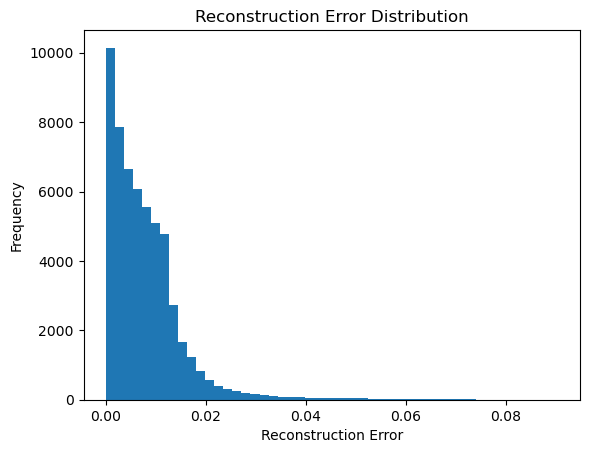

In [25]:
# Build simple autoencoder
input_dim = X_scaled.shape[1]
encoding_dim = 8

input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='relu')(input_layer)
decoded = Dense(input_dim, activation='linear')(encoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer='adam', loss='mse')

# Train autoencoder
history = autoencoder.fit(X_scaled, X_scaled, epochs=30, batch_size=64, shuffle=True, verbose=0)

# Reconstruction errors
reconstructions = autoencoder.predict(X_scaled)
mse = np.mean(np.power(X_scaled - reconstructions, 2), axis=1)

# Plot the distribution of reconstruction errors
plt.hist(mse, bins=50)
plt.xlabel('Reconstruction Error')
plt.ylabel('Frequency')
plt.title('Reconstruction Error Distribution')
plt.show()

In [26]:
# Set initial threshold
threshold = np.percentile(mse, 95)
print(f'Initial threshold: {threshold}')

insurance_df['Autoencoder_Anomaly'] = (mse > threshold).astype(int)
insurance_claim_df['Autoencoder_Anomaly'] = (mse > threshold).astype(int)

Initial threshold: 0.020292830893047856


`Note`: This means that 95% of the data points have reconstruction errors below this threshold, and the remaining 5% have errors above it.

Number of anomalies detected: 2775
Silhouette Score: 0.66


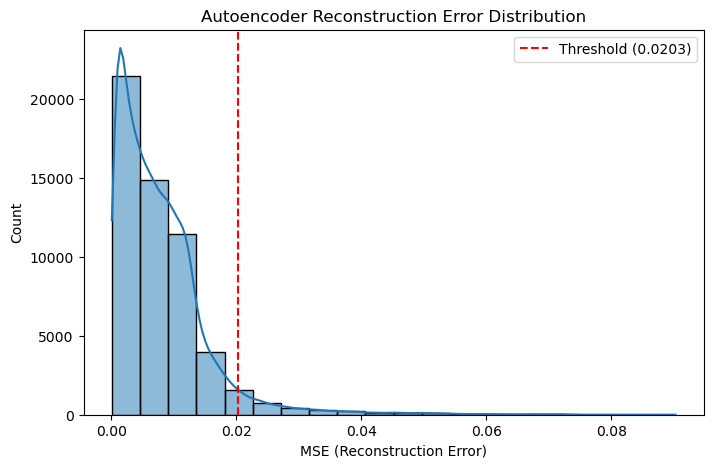

In [27]:
# Identify anomalies
anomalies = X_scaled[mse > threshold]
print(f'Number of anomalies detected: {len(anomalies)}')

# Clustering-based evaluation using K-means
kmeans = KMeans(n_clusters=2, random_state=42,n_init='auto')
kmeans.fit(mse.reshape(-1, 1))
cluster_labels = kmeans.labels_

# Evaluate the clustering using silhouette score
from sklearn.metrics import silhouette_score

silhouette_avg = silhouette_score(mse.reshape(-1, 1), cluster_labels)
print(f'Silhouette Score: {silhouette_avg:.2f}')

# Plot MSE distribution
plt.figure(figsize=(8,5))
sns.histplot(mse, bins=20, kde=True)
plt.axvline(threshold, color='r', linestyle='--', label=f"Threshold ({threshold:.4f})")
plt.title('Autoencoder Reconstruction Error Distribution')
plt.xlabel('MSE (Reconstruction Error)')
plt.legend()
plt.show()

`Note`: Any data point with a reconstruction error above this threshold is considered an anomaly. This approach helps in distinguishing normal data from outliers effectively.

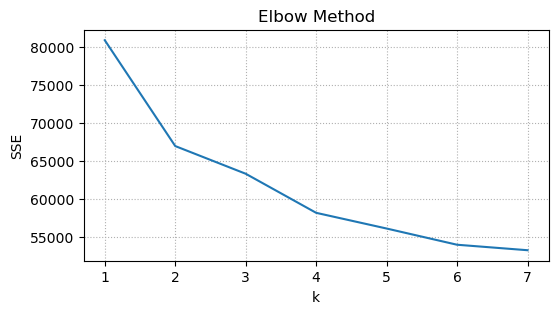

In [61]:
# Creat an Elbow method
sse = {}
K = range(1,8)
for k in K:
    kmeans = KMeans(n_clusters=k, n_init='auto').fit(X_scaled)
    sse[k]= kmeans.inertia_
    
# Plot
plt.figure(figsize=(6, 3))
plt.plot(list(sse.keys()), list(sse.values()))
plt.xlabel('k')
plt.ylabel('SSE')
plt.grid(True, linestyle=':')
plt.title('Elbow Method')
plt.show()

In [29]:
#  Clustering (KMeans)
kmeans = KMeans(n_clusters=2, random_state=42,n_init='auto')
cluster_labels = kmeans.fit_predict(X_scaled)

insurance_df['Cluster'] = cluster_labels
insurance_claim_df['Cluster'] = cluster_labels

In [30]:
# from sklearn.cluster import DBSCAN
# from sklearn.metrics import silhouette_score


# # Define the range of hyperparameters for the grid search
# eps_values = np.arange(0.1, 1.1, 0.1)
# min_samples_values = np.arange(3, 11)

# # Initialize variables to store the best parameters and the highest silhouette score
# best_eps = None
# best_min_samples = None
# best_silhouette_score = -1

# # Perform grid search
# for eps in eps_values:
#     for min_samples in min_samples_values:
#         # Apply DBSCAN with the current combination of eps and min_samples
#         dbscan = DBSCAN(eps=eps, min_samples=min_samples)
#         labels = dbscan.fit_predict(X_scaled)
        
#         # Calculate silhouette score if there are more than one cluster
#         if len(set(labels)) > 1:
#             score = silhouette_score(X_scaled, labels)
#             if score > best_silhouette_score:
#                 best_silhouette_score = score
#                 best_eps = eps
#                 best_min_samples = min_samples

# # Print the best parameters and the highest silhouette score
# print(f"Best eps: {best_eps}")
# print(f"Best min_samples: {best_min_samples}")
# print(f"Best silhouette score: {best_silhouette_score}")

```
Output: Best eps: 0.9
Best min_samples: 3
Best silhouette score: 0.16021101146846256
```

In [31]:
from sklearn.cluster import DBSCAN

# Plot the data with the best DBSCAN parameters
dbscan = DBSCAN(eps=0.9, min_samples=3)
labels = dbscan.fit_predict(X_scaled)

insurance_df['DB_Cluster'] = dbscan.labels_
insurance_claim_df['DB_Cluster'] = dbscan.labels_

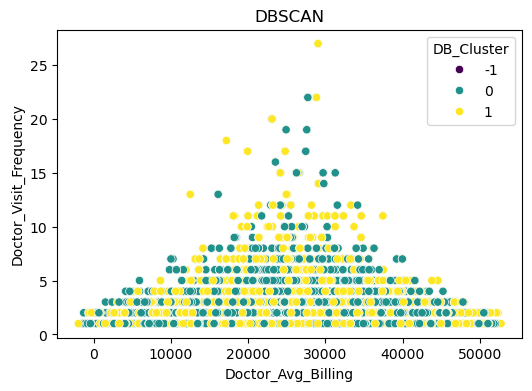

In [32]:
# Visualizing Clusters
plt.figure(figsize=(6, 4))
sns.scatterplot(x=insurance_df['Doctor_Avg_Billing'], y=insurance_df['Doctor_Visit_Frequency'], hue=insurance_df['DB_Cluster'], palette='viridis')
plt.title('DBSCAN')
plt.show()

In [33]:
# check the datasets
print(insurance_df.head())
print(insurance_claim_df.head())

   Age  Gender  Medical Condition  Insurance Provider  Billing Amount  \
0   30       1                  2                   1    18856.281306   
1   62       1                  5                   3    33643.327287   
2   76       0                  5                   0    27955.096079   
3   28       0                  3                   3    37909.782410   
4   43       0                  2                   0    14238.317814   

   Admission Type  Medication  Test Results  Stay_Duration  Billing_per_Day  \
0               2           3             2              2      9428.140653   
1               1           1             1              6      5607.221214   
2               1           0             2             15      1863.673072   
3               0           1             0             30      1263.659414   
4               2           4             0             20       711.915891   

   ...  Hospital_Avg_Billing  Hospital_Avg_Stay  Doctor_Visit_Frequency  \
0  ...     

In [34]:
cluster_count = insurance_df.groupby('Cluster')[['Hospital_Visit_Frequency', 'Doctor_Visit_Frequency']].sum()
cluster_count.round(2)

,Hospital_Visit_Frequency,Doctor_Visit_Frequency
Cluster,,
0,78931,55989
1,77803,56561


In [35]:
cluster_count = insurance_df.groupby('Autoencoder_Anomaly')[['Hospital_Visit_Frequency', 'Hospital_Avg_Billing']].describe()
cluster_count.T

Autoencoder_Anomaly                        0             1
Hospital_Visit_Frequency count  52725.000000   2775.000000
                         mean       2.287587     13.016577
                         std        2.811223     13.009497
                         min        1.000000      1.000000
                         25%        1.000000      1.000000
                         50%        1.000000      7.000000
                         75%        2.000000     23.000000
                         max       27.000000     44.000000
Hospital_Avg_Billing     count  52725.000000   2775.000000
                         mean   25397.620542  28231.531652
                         std    12818.659826  10231.581271
                         min    -2008.492140   -135.719073
                         25%    15532.395014  23016.327641
                         50%    25264.606951  27214.611790
                         75%    35126.157277  33055.669855
                         max    52373.032374  51350.512806

In [36]:
insurance_df.columns

Index(['Age', 'Gender', 'Medical Condition', 'Insurance Provider',
       'Billing Amount', 'Admission Type', 'Medication', 'Test Results',
       'Stay_Duration', 'Billing_per_Day', 'Hospital_Visit_Frequency',
       'Hospital_Avg_Billing', 'Hospital_Avg_Stay', 'Doctor_Visit_Frequency',
       'Doctor_Avg_Billing', 'Doctor_Avg_Stay', 'IsoForest_Anomaly',
       'LOF_Anomaly', 'Autoencoder_Anomaly', 'Cluster', 'DB_Cluster'],
      dtype='object')

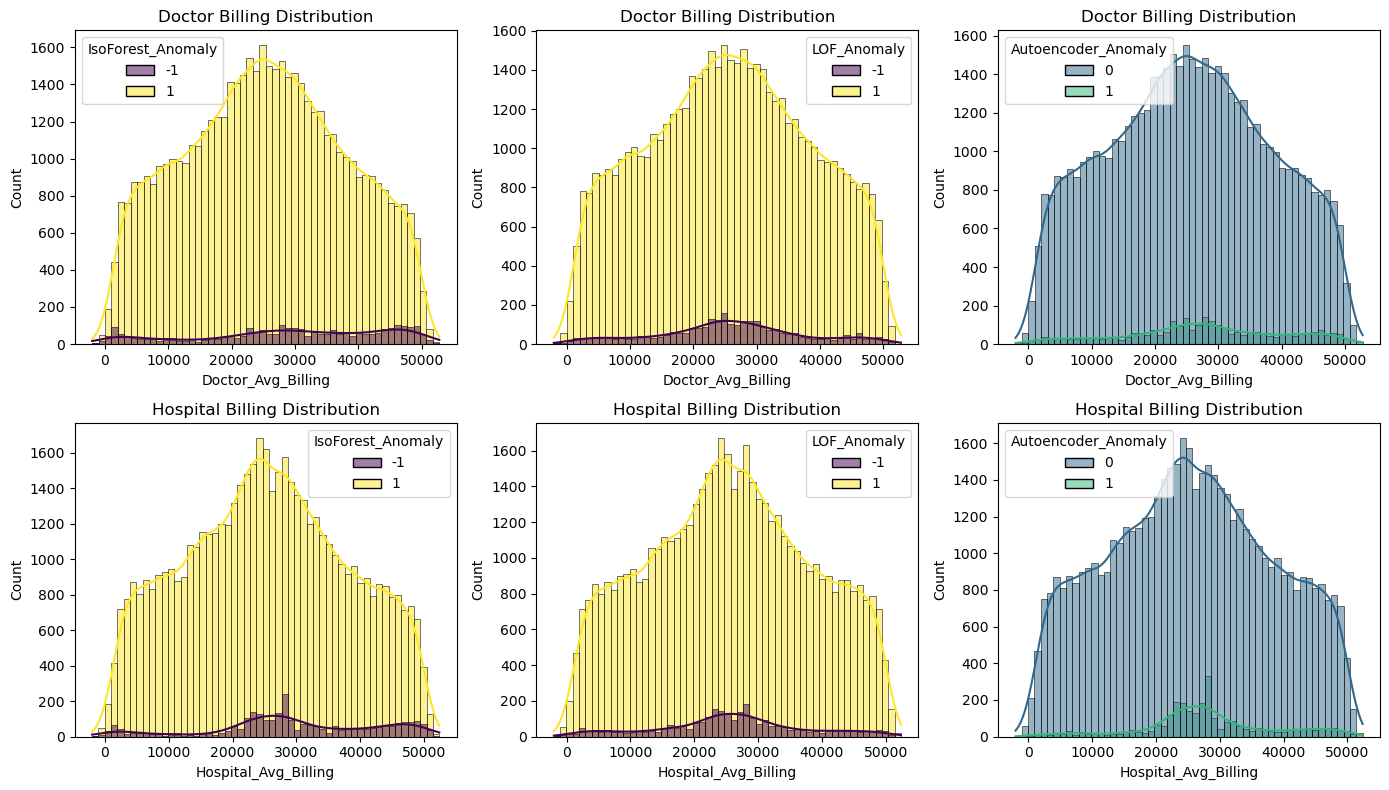

In [37]:
# Create a 1x2 grid layout
fig, axes = plt.subplots(2, 3, figsize=(14, 8))  

# Doctor Avg bill anomaly
sns.histplot(x='Doctor_Avg_Billing', hue='IsoForest_Anomaly', 
             palette='viridis', data=insurance_df, ax=axes[0, 0], kde=True)
axes[0,0].set_title("Doctor Billing Distribution", fontsize=12)

# Doctor Avg bill anomaly
sns.histplot(x='Doctor_Avg_Billing', hue='LOF_Anomaly', 
             palette='viridis', data=insurance_df, ax=axes[0, 1], kde=True)
axes[0,1].set_title("Doctor Billing Distribution", fontsize=12)

# Doctor Avg bill anomaly
sns.histplot(x='Doctor_Avg_Billing', hue='Autoencoder_Anomaly', 
             palette='viridis', data=insurance_df, ax=axes[0, 2], kde=True)
axes[0,2].set_title("Doctor Billing Distribution", fontsize=12)

# Hospital Avg bill anomaly
sns.histplot(x='Hospital_Avg_Billing', hue='IsoForest_Anomaly', 
                palette='viridis', data=insurance_df, ax=axes[1, 0], kde=True)
axes[1,0].set_title("Hospital Billing Distribution", fontsize=12)

# Hospital Avg bill anomaly
sns.histplot(x='Hospital_Avg_Billing', hue='LOF_Anomaly', 
                palette='viridis', data=insurance_df, ax=axes[1, 1], kde=True)
axes[1,1].set_title("Hospital Billing Distribution", fontsize=12)

# Hospital Avg bill anomaly
sns.histplot(x='Hospital_Avg_Billing', hue='Autoencoder_Anomaly', 
                palette='viridis', data=insurance_df, ax=axes[1, 2], kde=True)
axes[1,2].set_title("Hospital Billing Distribution", fontsize=12)


plt.tight_layout()
plt.show()

`Intepretation:`

The Isolation Forest results (top-left) show that most doctor billings fall between 10,000 and 40,000. Anomalies (marked in purple) mostly appeared at the extremes very low billings under 5,000 and very high billings over $45,000  which makes sense, as those amounts are quite rare.


The LOF results (top-middle) were similar, flagging both very low and very high billings as anomalies. However, LOF seemed a bit more selective, catching fewer anomalies overall, especially around the edges.


The Autoencoder (top-right) revealed a slightly different behavior. It mainly flagged high billing amounts as anomalies, while catching fewer low-billing cases compared to Isolation Forest and LOF. This suggests the Autoencoder focused more on inconsistencies at the higher end of the billing spectrum.


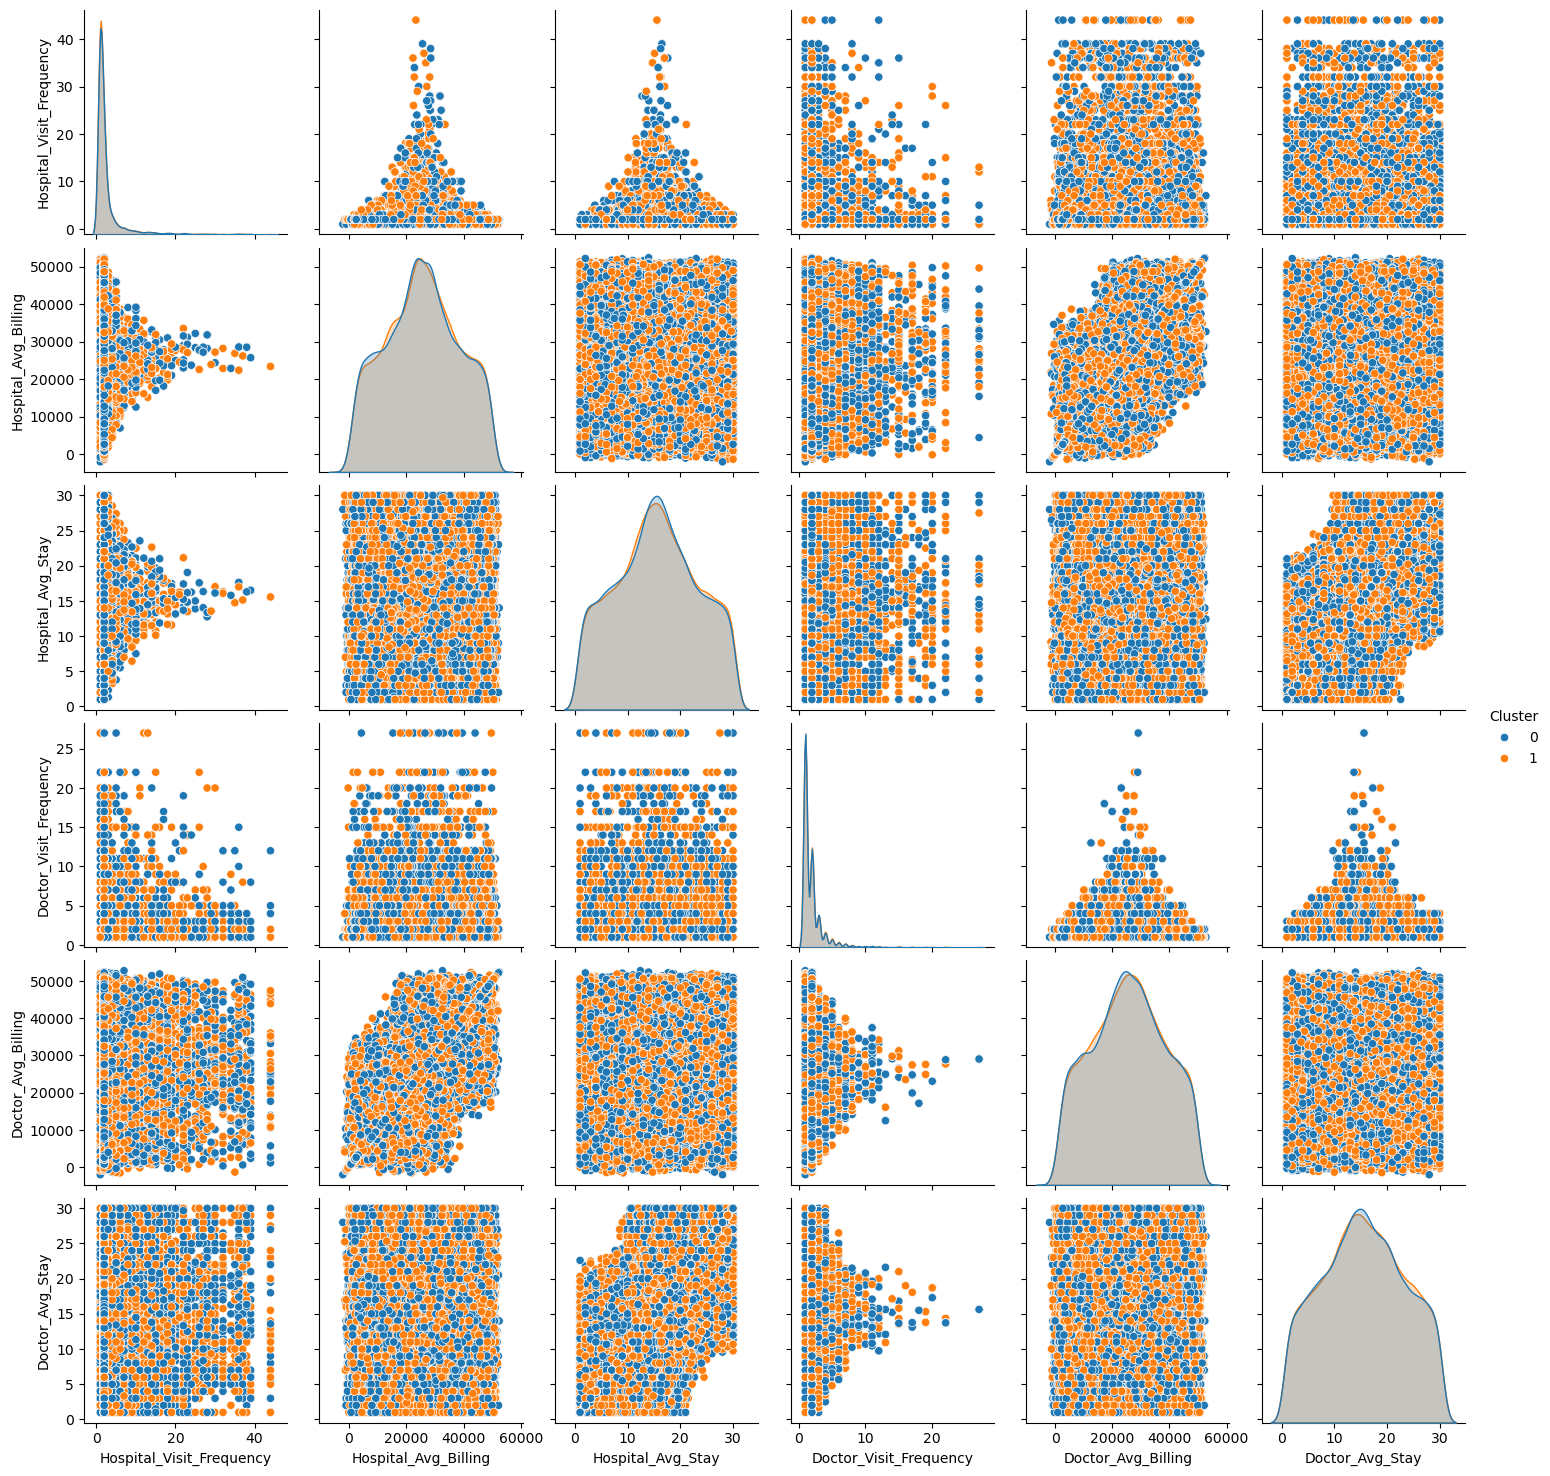

In [38]:
# Select variables for sns plot
selected_var = insurance_df[['Hospital_Visit_Frequency', 'Hospital_Avg_Billing', 'Hospital_Avg_Stay',
       'Doctor_Visit_Frequency', 'Doctor_Avg_Billing', 'Doctor_Avg_Stay', 'Cluster']]

# Create a pair plot 
sns.pairplot(selected_var, hue='Cluster', diag_kind='kde')
plt.show()

In [39]:
# Create anomaly scores report from all models

# Isolation Forest score
insurance_df['IsoForest_Score'] = iso_forest.decision_function(X_scaled)

# LOF score
insurance_df['LOF_Score'] = lof.negative_outlier_factor_

# Autoencoder MSE already computed 
insurance_df['Autoencoder_Score'] = mse

In [40]:
# Combine all the anomaly scores

# Normalize the scores
score_scaler = MinMaxScaler()

insurance_df[['IsoForest_Score_Norm', 'LOF_Score_Norm', 'Autoencoder_Score_Norm']] = score_scaler.fit_transform(
    insurance_df[['IsoForest_Score', 'LOF_Score', 'Autoencoder_Score']]
)

# Combine (higher = more risky)
insurance_df['Combined_Anomaly_Score'] = insurance_df[['IsoForest_Score_Norm', 'LOF_Score_Norm']].mean(axis=1)

# Sort patients by highest risk
df_sorted_risk = insurance_df.sort_values('Combined_Anomaly_Score', ascending=False)


In [41]:
insurance_df.head()

,Age,Gender,Medical Condition,Insurance Provider,Billing Amount,Admission Type,Medication,Test Results,Stay_Duration,Billing_per_Day,...,Autoencoder_Anomaly,Cluster,DB_Cluster,IsoForest_Score,LOF_Score,Autoencoder_Score,IsoForest_Score_Norm,LOF_Score_Norm,Autoencoder_Score_Norm,Combined_Anomaly_Score
0,30,1,2,1,18856.281306,2,3,2,2,9428.140653,...,1,1,0,-0.002545,-1.526156,0.032103,0.394477,0.405590,0.355205,0.400034
1,62,1,5,3,33643.327287,1,1,1,6,5607.221214,...,0,1,0,0.071723,-1.055159,0.005063,0.712414,0.832069,0.055421,0.772241
2,76,0,5,0,27955.096079,1,0,2,15,1863.673072,...,0,0,1,0.068706,-0.991067,0.006866,0.699501,0.890103,0.075410,0.794802
3,28,0,3,3,37909.782410,0,1,0,30,1263.659414,...,0,0,1,0.041406,-1.016515,0.006525,0.582628,0.867060,0.071628,0.724844
4,43,0,2,0,14238.317814,2,4,0,20,711.915891,...,0,0,1,0.080716,-1.009091,0.000939,0.750915,0.873783,0.009699,0.812349


In [42]:
insurance_df['Autoencoder_Anomaly'].value_counts()

Autoencoder_Anomaly
0    52725
1     2775
Name: count, dtype: int64

In [43]:
# Build an outlier report

# first define anomalies
df_sorted_risk['Top_Anomaly_Flag'] = (df_sorted_risk['Combined_Anomaly_Score'] > 0.9).astype(int)

# display the report
outlier_report = df_sorted_risk[['Age', 'Gender', 'Billing Amount', 'Stay_Duration', 
                                 'IsoForest_Anomaly', 'LOF_Anomaly', 'Autoencoder_Anomaly', 
                                 'Combined_Anomaly_Score', 'Top_Anomaly_Flag']]

outlier_report

,Age,Gender,Billing Amount,Stay_Duration,IsoForest_Anomaly,LOF_Anomaly,Autoencoder_Anomaly,Combined_Anomaly_Score,Top_Anomaly_Flag
27146,38,1,25366.158900,18,1,1,0,0.957073,1
33577,51,1,27604.775538,18,1,1,0,0.952613,1
20191,53,1,21984.345498,19,1,1,0,0.947490,1
19902,40,1,19974.050581,19,1,1,0,0.946353,1
17978,46,0,24362.974467,14,1,1,0,0.945508,1
...,...,...,...,...,...,...,...,...,...
22180,22,1,1955.368518,27,-1,-1,1,0.231951,0
38482,28,0,6534.083325,28,-1,-1,1,0.200777,0
14939,48,1,42238.816365,3,-1,-1,1,0.179633,0
40957,85,0,44537.271641,1,-1,-1,1,0.151377,0


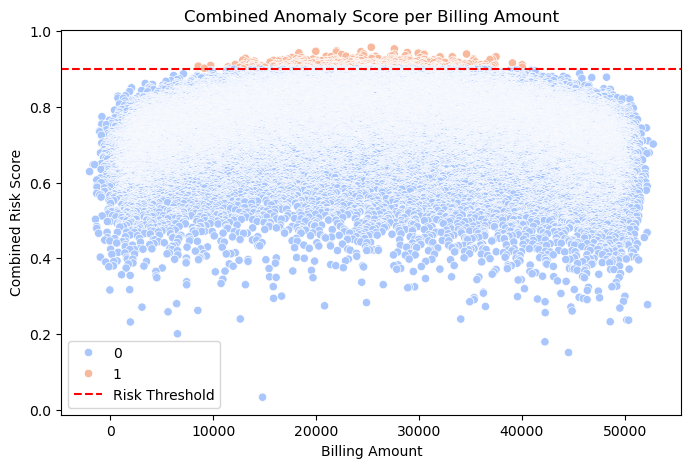

In [44]:
# plot of risky claims
plt.figure(figsize=(8,5))
sns.scatterplot(x=df_sorted_risk['Billing Amount'], y=df_sorted_risk['Combined_Anomaly_Score'],
                hue=df_sorted_risk['Top_Anomaly_Flag'], palette='coolwarm')
plt.title('Combined Anomaly Score per Billing Amount')
plt.xlabel('Billing Amount')
plt.ylabel('Combined Risk Score')
plt.axhline(0.9, color='red', linestyle='--', label='Risk Threshold')
plt.legend()
plt.show()

In [45]:
# Verify the counts of normal and anomalous data points
print(df_sorted_risk['Top_Anomaly_Flag'].value_counts())

Top_Anomaly_Flag
0    54972
1      528
Name: count, dtype: int64


### Intepretation

* Risk Threshold: A horizontal dashed red line indicates a "Risk Threshold" at a combined risk score of approximately 0.9.
* Anomaly Identification: Data points above this threshold are likely considered anomalies or high-risk instances based on the model's assessment. we can see a cluster of orange/red points above this threshold, primarily concentrated in the mid-range of billing amounts (roughly between 10,000 and 40,000).
* Distribution: The majority of data points have lower combined risk scores, suggesting that most instances are considered normal. The distribution seems denser in the lower risk score regions across various billing amounts.
* Billing Amount vs. Risk: While there are high-risk instances across a range of billing amounts, they appear more concentrated in the middle range. Very low and very high billing amounts seem to have predominantly lower risk scores. 

In [46]:
# Filter High-Risk Doctors and Hospitals
# first, Combine anomalies from the models
# Majority voting or strict voting
insurance_claim_df['Anomaly_Votes'] = insurance_claim_df[['IsoForest_Anomaly', 'LOF_Anomaly']].sum(axis=1)
insurance_df['Anomaly_Votes'] = insurance_df[['IsoForest_Anomaly', 'LOF_Anomaly']].sum(axis=1)

# Define high risk: flagged by at least 2 models
insurance_claim_df['High_Risk'] = insurance_claim_df['Anomaly_Votes'].apply(lambda x: 1 if x >= 1 else 0)

insurance_df['High_Risk'] = insurance_df['Anomaly_Votes'].apply(lambda x: 1 if x >= 1 else 0)

# then, filter risky claims
# Get only high-risk claims
high_risk_claims = insurance_claim_df[insurance_claim_df['High_Risk'] >= 1]
high_risk_claims.head()

,Age,Gender,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,...,Doctor_Visit_Frequency,Doctor_Avg_Billing,Doctor_Avg_Stay,IsoForest_Anomaly,LOF_Anomaly,Autoencoder_Anomaly,Cluster,DB_Cluster,Anomaly_Votes,High_Risk
1,62,1,5,2019-08-20,Samantha Davies,Kim Inc,3,33643.327287,265,1,...,1,33643.327287,6.0,1,1,0,1,0,2,1
2,76,0,5,2022-09-22,Tiffany Mitchell,Cook PLC,0,27955.096079,205,1,...,1,27955.096079,15.0,1,1,0,0,1,2,1
3,28,0,3,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",3,37909.782410,450,0,...,1,37909.782410,30.0,1,1,0,0,1,2,1
4,43,0,2,2022-09-19,Kathleen Hanna,White-White,0,14238.317814,458,2,...,2,14238.317814,20.0,1,1,0,0,1,2,1
5,36,1,1,2023-12-20,Taylor Newton,Nunez-Humphrey,4,48145.110951,389,2,...,1,48145.110951,4.0,1,1,0,1,0,2,1


In [47]:
insurance_df.head()

,Age,Gender,Medical Condition,Insurance Provider,Billing Amount,Admission Type,Medication,Test Results,Stay_Duration,Billing_per_Day,...,DB_Cluster,IsoForest_Score,LOF_Score,Autoencoder_Score,IsoForest_Score_Norm,LOF_Score_Norm,Autoencoder_Score_Norm,Combined_Anomaly_Score,Anomaly_Votes,High_Risk
0,30,1,2,1,18856.281306,2,3,2,2,9428.140653,...,0,-0.002545,-1.526156,0.032103,0.394477,0.405590,0.355205,0.400034,-2,0
1,62,1,5,3,33643.327287,1,1,1,6,5607.221214,...,0,0.071723,-1.055159,0.005063,0.712414,0.832069,0.055421,0.772241,2,1
2,76,0,5,0,27955.096079,1,0,2,15,1863.673072,...,1,0.068706,-0.991067,0.006866,0.699501,0.890103,0.075410,0.794802,2,1
3,28,0,3,3,37909.782410,0,1,0,30,1263.659414,...,1,0.041406,-1.016515,0.006525,0.582628,0.867060,0.071628,0.724844,2,1
4,43,0,2,0,14238.317814,2,4,0,20,711.915891,...,1,0.080716,-1.009091,0.000939,0.750915,0.873783,0.009699,0.812349,2,1


In [48]:
high_risk_claims.shape

(50663, 28)

In [49]:
insurance_claim_df.columns

Index(['Age', 'Gender', 'Medical Condition', 'Date of Admission', 'Doctor',
       'Hospital', 'Insurance Provider', 'Billing Amount', 'Room Number',
       'Admission Type', 'Discharge Date', 'Medication', 'Test Results',
       'Stay_Duration', 'Billing_per_Day', 'Hospital_Visit_Frequency',
       'Hospital_Avg_Billing', 'Hospital_Avg_Stay', 'Doctor_Visit_Frequency',
       'Doctor_Avg_Billing', 'Doctor_Avg_Stay', 'IsoForest_Anomaly',
       'LOF_Anomaly', 'Autoencoder_Anomaly', 'Cluster', 'DB_Cluster',
       'Anomaly_Votes', 'High_Risk'],
      dtype='object')

In [50]:
insurance_claim_df['High_Risk'].value_counts()

High_Risk
1    50663
0     4837
Name: count, dtype: int64

In [51]:
# Check risky hospitals
risky_hospitals = high_risk_claims['Hospital'].value_counts()

# Check risky doctors
risky_doctors = high_risk_claims['Doctor'].value_counts()

# rank hospitals/doctors by how often they appear in high-risk claims:
risky_hospitals = risky_hospitals.sort_values(ascending=False)
print('Top 5 hospitals appear in high-risk claims:', risky_hospitals.head())
print("-"*40)
risky_doctors = risky_doctors.sort_values(ascending=False)
print('Top 5 doctors appear in high-risk claims:',risky_doctors.head())

Top 5 hospitals appear in high-risk claims: Hospital
PLC Rodriguez        14
Lopez PLC            14
Martin Inc           14
and Sons Williams    13
PLC Thompson         13
Name: count, dtype: int64
----------------------------------------
Top 5 doctors appear in high-risk claims: Doctor
Michael Rodriguez    9
Heather Williams     9
Jennifer Brown       8
David Jones          8
Stephanie Smith      8
Name: count, dtype: int64


In [52]:
# Building the Risk Table
# Group by Doctor and Hospital
doctor_risk_table = high_risk_claims.groupby('Doctor').agg(
    High_Risk_Claims=('High_Risk', 'sum'),
    Avg_Billing=('Billing Amount', 'mean'),
    Avg_Stay=('Stay_Duration', 'mean'),
    Anomaly_Score=('Anomaly_Votes', 'mean')
).reset_index()

hospital_risk_table = high_risk_claims.groupby('Hospital').agg(
    High_Risk_Claims=('High_Risk', 'sum'),
    Avg_Billing=('Billing Amount', 'mean'),
    Avg_Stay=('Stay_Duration', 'mean'),
    Anomaly_Score=('Anomaly_Votes', 'mean')
).reset_index()

# Create a risk matrix for doctors
doctor_risk_matrix = doctor_risk_table[['High_Risk_Claims', 'Avg_Billing', 'Avg_Stay', 'Anomaly_Score']]

# Create a risk matrix for hospitals
hospital_risk_matrix = hospital_risk_table[['High_Risk_Claims', 'Avg_Billing', 'Avg_Stay', 'Anomaly_Score']]

In [53]:
# Load libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
from imblearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE

# copy the data
high_risk_claims_df = insurance_df.copy()
high_risk_claims_df.columns

Index(['Age', 'Gender', 'Medical Condition', 'Insurance Provider',
       'Billing Amount', 'Admission Type', 'Medication', 'Test Results',
       'Stay_Duration', 'Billing_per_Day', 'Hospital_Visit_Frequency',
       'Hospital_Avg_Billing', 'Hospital_Avg_Stay', 'Doctor_Visit_Frequency',
       'Doctor_Avg_Billing', 'Doctor_Avg_Stay', 'IsoForest_Anomaly',
       'LOF_Anomaly', 'Autoencoder_Anomaly', 'Cluster', 'DB_Cluster',
       'IsoForest_Score', 'LOF_Score', 'Autoencoder_Score',
       'IsoForest_Score_Norm', 'LOF_Score_Norm', 'Autoencoder_Score_Norm',
       'Combined_Anomaly_Score', 'Anomaly_Votes', 'High_Risk'],
      dtype='object')

In [54]:
# selected columns
high_risk_claims_df = insurance_df[['Age', 'Gender', 'Medical Condition', 'Insurance Provider',
                             'Admission Type', 'Medication','Test Results', 'Stay_Duration', 'Billing_per_Day', 'Hospital_Visit_Frequency', 
                             'Hospital_Avg_Billing', 'Hospital_Avg_Stay', 'Doctor_Visit_Frequency', 'High_Risk']]


In [55]:
high_risk_claims_df.shape

(55500, 14)

In [56]:
# Select useful features
features = high_risk_claims_df.drop('High_Risk', axis=1)
target = 'High_Risk'

# Standardize features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Prepare data
X = features_scaled
y = high_risk_claims_df[target]

In [57]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Define pipeline
pipe = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression())  
])

# Define search space
search_space = [
    {
        'classifier': [LogisticRegression(class_weight='balanced')],
        'classifier__solver': ['liblinear'],
        'classifier__penalty': ['l1', 'l2'],
        'classifier__C': np.logspace(0, 4, 10)
    },
#     {
#         'classifier': [RandomForestClassifier(class_weight='balanced')],
#         'classifier__n_estimators': [100, 200],
#         'classifier__max_features': [1, 2, 3]
#     }
    ]

# Grid search
clf = GridSearchCV(estimator=pipe, param_grid=search_space, cv=5, n_jobs=-1, verbose=1)
clf.fit(X_train, y_train)

# Evaluate
print("Best Parameters:", clf.best_params_)
print("Best Cross-Validation Score: {:.2f}".format(clf.best_score_))
print("Test Set Score: {:.2f}".format(clf.best_estimator_.score(X_test, y_test)))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'classifier': LogisticRegression(class_weight='balanced'), 'classifier__C': 1.0, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
Best Cross-Validation Score: 0.87
Test Set Score: 0.86


In [58]:
high_risk_claims_df['High_Risk'].value_counts()

High_Risk
1    50663
0     4837
Name: count, dtype: int64

Training Data Score: 0.8676351351351351
Accuracy of the best model on test dataset: 0.86
              precision    recall  f1-score   support

           0       0.36      0.71      0.47       967
           1       0.97      0.88      0.92     10133

    accuracy                           0.86     11100
   macro avg       0.66      0.79      0.70     11100
weighted avg       0.92      0.86      0.88     11100



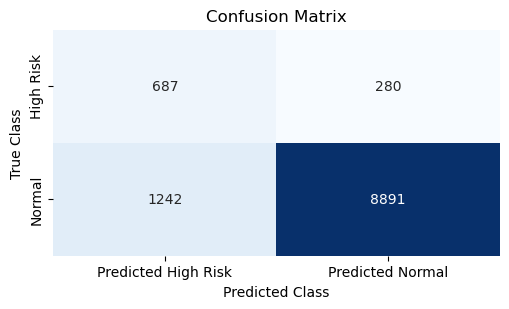

In [59]:
# Evaluate the model
training_score = clf.score(X_train, y_train)
print(f"Training Data Score: {training_score}")

# Predict on the test data
y_pred = clf.predict(X_test)

# Print the accuracy of the model
accuracy = clf.score(X_test, y_test)

print(f"Accuracy of the best model on test dataset: {accuracy:.2f}")

# Create a confusion matrix for the test set predictions
y_true_val = y_test
y_prediction = clf.predict(X_test)

# print out the confusion matrix for the predicted outcome
conf_matrix = confusion_matrix(y_true_val, y_prediction)

# Generate a classification report for accuracy, precision, recall, and F1.
print(classification_report(y_true_val, y_prediction))

# Create a DataFrame from the confusion matrix.
matrix_df = pd.DataFrame(
    conf_matrix, index=["High Risk", "Normal"], columns=["Predicted High Risk", "Predicted Normal"])

# create heatmap
plt.figure(figsize=(5,3))
sns.heatmap(matrix_df, annot=True, cbar=None, cmap="Blues", fmt='g')
plt.title("Confusion Matrix"), plt.tight_layout()
plt.ylabel("True Class"), plt.xlabel("Predicted Class")
plt.show()

###  Interpretation 

The model demonstrates a training score of 0.855, meaning it correctly predicts approximately 85.5% of the training set, and a test accuracy of 0.85, showing consistency in performance across both the training and test datasets. This suggests that overfitting is minimal. However, as is typical in imbalanced datasets, accuracy alone doesn’t fully capture the model’s performance, especially in terms of class balance.

Looking at the class-wise performance, Class 0 (representing high-risk or fraudulent claims) shows a precision of 0.33, meaning only 33% of the predicted high-risk claims are accurate. The recall of 0.69 indicates the model correctly identifies 69% of all actual high-risk cases, with a moderate F1-score of 0.45. In contrast, Class 1 (representing normal claims) shows much stronger results, with precision of 0.97 and recall of 0.87, giving it a strong F1-score of 0.91, indicating a well-balanced performance for the majority class. The macro average reveals lower precision (0.65) and recall (0.78), reflecting the imbalance between the classes, while the weighted average (F1-score of 0.87) is dominated by the majority class.

The confusion matrix and heatmap provide further insight into model performance, showing a reasonable number of true positives for Class 0 but also highlighting the presence of false positives, where normal claims are incorrectly classified as high-risk. Overall, the model shows improvements in detecting high-risk claims with a 69% recall and 33% precision for Class 0. If missing fraudulent claims is a costly mistake, a higher recall is essential, and the model is progressing well in this direction, though improving precision would further refine its usefulness.
